<a href="https://colab.research.google.com/github/pranojit9/AI-In-Healthcare-Roll-2671504-Pranojit_Roy/blob/main/Coding_Assignment_3/python_script_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.

Dataset downloaded successfully!
Dataset Location:
/kaggle/input/breast-ultrasound-images-dataset

DATASET FOLDER STRUCTURE
breast-ultrasound-images-dataset/
    Dataset_BUSI_with_GT/
        benign/
        normal/
        malignant/

IMAGE FOLDERS

Folder : /kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign
Images : 891

Folder : /kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/normal
Images : 266

Folder : /kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/malignant
Images : 421

CLASS DISTRIBUTION
benign          : 891
normal          : 266
malignant       : 421
----------------------------------------
Total Images : 1578

DATASET READY
Use the folder below as your dataset directory:
/kaggle/input/breast-ultrasound-images-dataset
Image Preprocessing Pipeline Created Successfully

Training Transformations:
Compose(
    Resize(size=(128, 

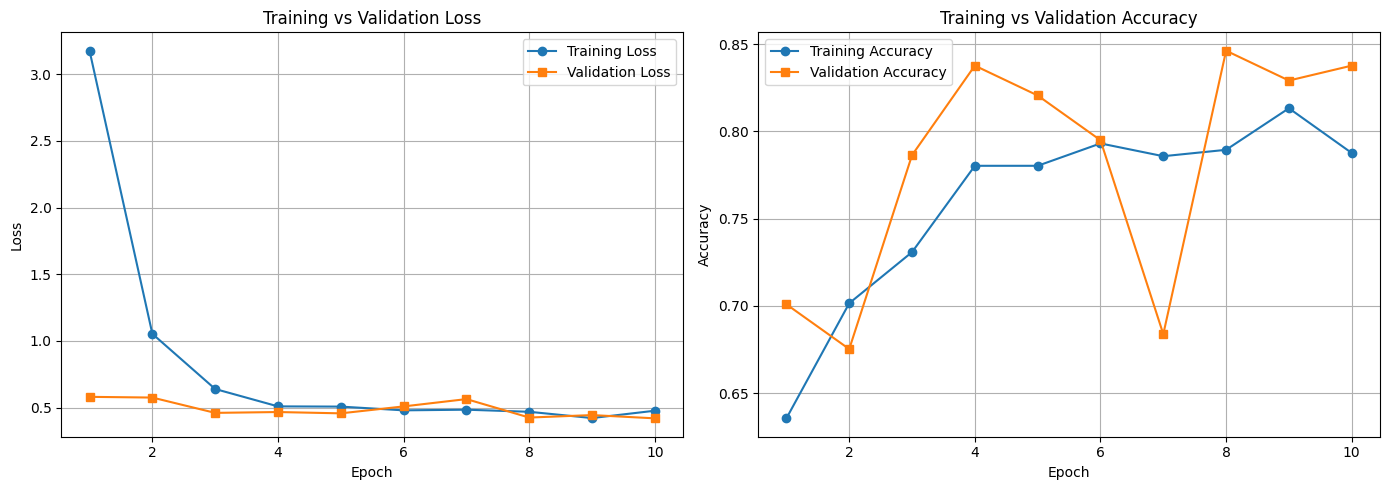

Learning Curve saved as 'learning_curve.png'


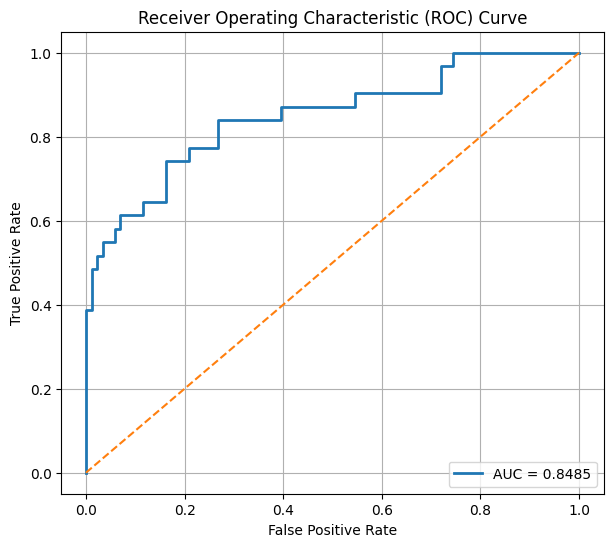

ROC-AUC Score : 0.8485

ROC Curve saved as 'roc_curve.png'


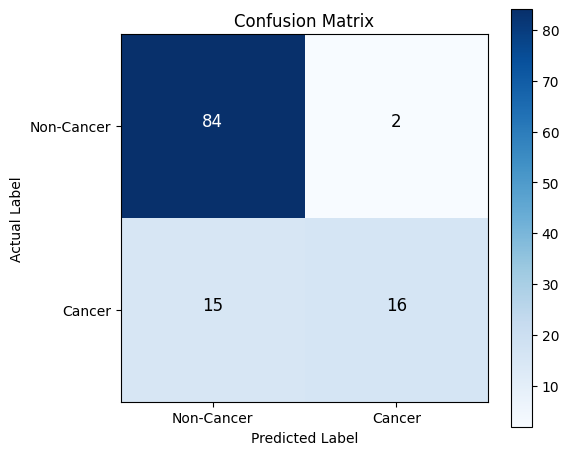

Confusion Matrix saved as 'confusion_matrix.png'


In [3]:
# ============================================================
# Image-Based Cancer Diagnosis Using CNNs
# Step 1: Dataset Loading and Exploration
# ============================================================

import os
import kagglehub
import numpy as np

# ------------------------------------------------------------
# Download the latest version of the BUSI Dataset
# ------------------------------------------------------------
print("Downloading BUSI dataset...")

dataset_path = kagglehub.dataset_download(
    "sabahesaraki/breast-ultrasound-images-dataset"
)

print("\nDataset downloaded successfully!")
print(f"Dataset Location:\n{dataset_path}")

# ------------------------------------------------------------
# Display Folder Structure
# ------------------------------------------------------------
print("\n" + "="*60)
print("DATASET FOLDER STRUCTURE")
print("="*60)

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

# ------------------------------------------------------------
# Locate Image Folders
# ------------------------------------------------------------
print("\n" + "="*60)
print("IMAGE FOLDERS")
print("="*60)

image_extensions = (".png", ".jpg", ".jpeg")

image_folders = []

for root, dirs, files in os.walk(dataset_path):
    image_files = [
        f for f in files
        if f.lower().endswith(image_extensions)
    ]

    if len(image_files) > 0:
        image_folders.append(root)
        print(f"\nFolder : {root}")
        print(f"Images : {len(image_files)}")

# ------------------------------------------------------------
# Count Images in Each Class
# ------------------------------------------------------------
print("\n" + "="*60)
print("CLASS DISTRIBUTION")
print("="*60)

total_images = 0

for folder in image_folders:

    class_name = os.path.basename(folder)

    count = len([
        f for f in os.listdir(folder)
        if f.lower().endswith(image_extensions)
    ])

    total_images += count

    print(f"{class_name:<15} : {count}")

print("-"*40)
print(f"Total Images : {total_images}")

# ------------------------------------------------------------
# Final Dataset Directory
# ------------------------------------------------------------
print("\n" + "="*60)
print("DATASET READY")
print("="*60)

print("Use the folder below as your dataset directory:")

print(dataset_path)

# ============================================================
# Step 2: Image Preprocessing
# Resize + Augmentation + Tensor Conversion + Normalization
# ============================================================

import torch
from torchvision import transforms

# ------------------------------------------------------------
# Image Size
# ------------------------------------------------------------
IMAGE_SIZE = 128

# ------------------------------------------------------------
# Mean and Standard Deviation
# (Common normalization values for RGB images)
# ------------------------------------------------------------
MEAN = [0.5, 0.5, 0.5]
STD = [0.5, 0.5, 0.5]

# ------------------------------------------------------------
# Training Transformations
# ------------------------------------------------------------
train_transform = transforms.Compose([

    # Resize all images
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Data Augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),

    # Convert PIL Image to Tensor
    transforms.ToTensor(),

    # Normalize
    transforms.Normalize(mean=MEAN, std=STD)

])

# ------------------------------------------------------------
# Validation & Test Transformations
# (No augmentation)
# ------------------------------------------------------------
test_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(mean=MEAN, std=STD)

])

print("="*60)
print("Image Preprocessing Pipeline Created Successfully")
print("="*60)

print("\nTraining Transformations:")
print(train_transform)

print("\nValidation/Test Transformations:")
print(test_transform)

# ============================================================
# Step 3: Dataset Splitting and DataLoader Creation
# ============================================================

import os
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Collect Image Paths and Labels
# ------------------------------------------------------------

image_paths = []
labels = []

# Update this path if needed
dataset_dir = os.path.join(dataset_path, "Dataset_BUSI_with_GT")

class_mapping = {
    "benign": 0,
    "normal": 0,
    "malignant": 1
}

for class_name, label in class_mapping.items():

    class_folder = os.path.join(dataset_dir, class_name)

    if not os.path.exists(class_folder):
        continue

    for file in os.listdir(class_folder):

        # Ignore mask images
        if "mask" in file.lower():
            continue

        if file.endswith((".png", ".jpg", ".jpeg")):

            image_paths.append(os.path.join(class_folder, file))
            labels.append(label)

print(f"Total Images : {len(image_paths)}")
print(f"Total Labels : {len(labels)}")

# ------------------------------------------------------------
# Stratified Split
# ------------------------------------------------------------

# 70% Train
# 30% Temp

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

# Split remaining 30%
# 15% Validation
# 15% Test

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("\nDataset Split")
print("---------------------------")
print("Training   :", len(train_paths))
print("Validation :", len(val_paths))
print("Testing    :", len(test_paths))

# ------------------------------------------------------------
# Custom Dataset
# ------------------------------------------------------------

class BUSIDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):

        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, index):

        image = Image.open(self.image_paths[index]).convert("RGB")

        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image, label

# ------------------------------------------------------------
# Create Dataset Objects
# ------------------------------------------------------------

train_dataset = BUSIDataset(
    train_paths,
    train_labels,
    transform=train_transform
)

val_dataset = BUSIDataset(
    val_paths,
    val_labels,
    transform=test_transform
)

test_dataset = BUSIDataset(
    test_paths,
    test_labels,
    transform=test_transform
)

# ------------------------------------------------------------
# Create DataLoaders
# ------------------------------------------------------------

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nDataLoaders Created Successfully!")

print(f"Training Batches   : {len(train_loader)}")
print(f"Validation Batches : {len(val_loader)}")
print(f"Testing Batches    : {len(test_loader)}")

# ============================================================
# Step 4: Build Custom CNN Model
# ============================================================

import torch
import torch.nn as nn

# ------------------------------------------------------------
# CNN Architecture
# ------------------------------------------------------------

class CancerCNN(nn.Module):

    def __init__(self):
        super(CancerCNN, self).__init__()

        # ----------------------------
        # Feature Extraction
        # ----------------------------

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Dropout
            nn.Dropout(0.5)
        )

        # ----------------------------
        # Classification Head
        # ----------------------------

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 16 * 16, 256),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, 1),

            nn.Sigmoid()
        )

    # ----------------------------
    # Forward Pass
    # ----------------------------

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


# ------------------------------------------------------------
# Create Model
# ------------------------------------------------------------

model = CancerCNN()

print("="*60)
print("Custom CNN Model")
print("="*60)

print(model)

# ============================================================
# Step 5: Training Configuration
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

# ------------------------------------------------------------
# Device Configuration
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("Device:", device)
print("=" * 60)

# Move model to device
model = model.to(device)

# ------------------------------------------------------------
# Loss Function
# ------------------------------------------------------------

criterion = nn.BCELoss()

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ------------------------------------------------------------
# Training Parameters
# ------------------------------------------------------------

EPOCHS = 10

# ------------------------------------------------------------
# Store Training History
# ------------------------------------------------------------

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

print("\nTraining Configuration Ready!")

print(f"Loss Function : {criterion}")
print(f"Optimizer     : Adam")
print(f"Learning Rate : 0.001")
print(f"Epochs        : {EPOCHS}")

# ============================================================
# Step 6: Train the CNN Model
# ============================================================

for epoch in range(EPOCHS):

    # -----------------------------
    # Training Phase
    # -----------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.float().unsqueeze(1).to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predicted = (outputs >= 0.5).float()

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # -----------------------------
    # Validation Phase
    # -----------------------------
    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            predicted = (outputs >= 0.5).float()

            correct += (predicted == labels).sum().item()

            total += labels.size(0)

    val_loss = running_val_loss / total
    val_accuracy = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # -----------------------------
    # Print Epoch Results
    # -----------------------------
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

print("\nTraining Completed Successfully!")

# ============================================================
# Step 7: Model Testing and Performance Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# ------------------------------------------------------------
# Evaluation Mode
# ------------------------------------------------------------

model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.float().unsqueeze(1).to(device)

        # Forward pass
        outputs = model(images)

        # Predicted probability
        probabilities = outputs.squeeze().cpu().numpy()

        # Binary prediction
        predictions = (outputs >= 0.5).float().squeeze().cpu().numpy()

        # Store results
        y_prob.extend(np.atleast_1d(probabilities))
        y_pred.extend(np.atleast_1d(predictions))
        y_true.extend(labels.squeeze().cpu().numpy())

# ------------------------------------------------------------
# Performance Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)

# ------------------------------------------------------------
# Display Results
# ------------------------------------------------------------

print("=" * 60)
print("TEST PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report")
print("=" * 60)
print(classification_report(y_true, y_pred))

# ============================================================
# Step 8: Learning Curves
# ============================================================

import matplotlib.pyplot as plt

# Epoch numbers
epochs = range(1, EPOCHS + 1)

# ------------------------------------------------------------
# Create Figure
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

# ------------------------------------------------------------
# Loss Curve
# ------------------------------------------------------------

plt.subplot(1, 2, 1)

plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.plot(epochs, val_losses, marker='s', label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# ------------------------------------------------------------
# Accuracy Curve
# ------------------------------------------------------------

plt.subplot(1, 2, 2)

plt.plot(epochs, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(epochs, val_accuracies, marker='s', label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# ------------------------------------------------------------
# Save Figure
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig("learning_curve.png", dpi=300)

plt.show()

print("Learning Curve saved as 'learning_curve.png'")

# ============================================================
# Step 9: ROC Curve and AUC Score
# ============================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Calculate ROC Curve
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

roc_auc = auc(fpr, tpr)

# ------------------------------------------------------------
# Plot ROC Curve
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

# Random Guess Line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("Receiver Operating Characteristic (ROC) Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")

plt.grid(True)

# ------------------------------------------------------------
# Save Figure
# ------------------------------------------------------------

plt.savefig("roc_curve.png", dpi=300)

plt.show()

print(f"ROC-AUC Score : {roc_auc:.4f}")

print("\nROC Curve saved as 'roc_curve.png'")

# ============================================================
# Step 10: Confusion Matrix Heatmap
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Compute Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

# ------------------------------------------------------------
# Plot Confusion Matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

plt.title("Confusion Matrix")

plt.colorbar()

classes = ["Non-Cancer", "Cancer"]

tick_marks = range(len(classes))

plt.xticks(tick_marks, classes)

plt.yticks(tick_marks, classes)

# ------------------------------------------------------------
# Add Numbers Inside Cells
# ------------------------------------------------------------

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            horizontalalignment="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=12
        )

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.ylabel("Actual Label")

plt.xlabel("Predicted Label")

plt.tight_layout()

# ------------------------------------------------------------
# Save Figure
# ------------------------------------------------------------

plt.savefig("confusion_matrix.png", dpi=300)

plt.show()

print("Confusion Matrix saved as 'confusion_matrix.png'")